In [1]:
import warnings

warnings.filterwarnings('ignore') 

In [2]:
ensemble_dir = "../qgis_tifs/ensembles"
out_csv = "comparacao_baselines.csv"

IBGE_DATA = {
    "Taiobeiras": 33629.5,
    "Santana_do_Paraiso": 7167.4,
    "Belo_Oriente": 8408.4,
    "Carbonita": 35746.6,
    "Sao_Joao_do_Paraiso": 44185.2,
    "Ipaba": 2453.8,
    "Josenopolis": 11345.5,
    "Veredinha": 12602.2,
    "Minas_Novas": 35104.8,
    "Itamarandiba": 52205.0
}

IEF_DATA = {
    "Taiobeiras": 16550.0,
    "Santana_do_Paraiso": 7000.0,
    "Belo_Oriente": 9750.0,
    "Carbonita": 39500.0,
    "Sao_Joao_do_Paraiso": 48001.0,
    "Ipaba": 2650.0,
    "Josenopolis": 7650.0,
    "Veredinha": 12860.0,
    "Minas_Novas": 37057.0,
    "Itamarandiba": 78300.0
}


In [3]:
import glob
import os

tifs = sorted(glob.glob(os.path.join(ensemble_dir, "*.tif")))

In [ ]:
import numpy as np
import pandas as pd
import rasterio

results = []

for tif_path in tifs:
    filename  = os.path.basename(tif_path)
    city_name = None

    for key in IBGE_DATA.keys():
        if key in filename:
            city_name = key
            break

    config_name = (filename.replace(f"{city_name}_", "").replace(".tif", ""))

    with rasterio.open(tif_path) as src:
        mask = src.read(1)
        res_x, res_y = src.res

        pixel_area_m2   = res_x * res_y
        positive_pixels = np.count_nonzero(mask == 1)

        predicted_area_ha = (positive_pixels * pixel_area_m2) / 10000.0

    ibge_area_ha = IBGE_DATA[city_name]
    ief_area_ha  = IEF_DATA.get(city_name, np.nan)

    diff_ibge = (predicted_area_ha - ibge_area_ha)
    erro_ibge = (diff_ibge / ibge_area_ha) * 100

    if pd.notna(ief_area_ha):
        diff_ief = (predicted_area_ha - ief_area_ha)
        erro_ief = (diff_ief / ief_area_ha) * 100

    else:
        diff_ief = np.nan
        erro_ief = np.nan

    results.append({"Cidade": city_name.replace("_", " "),
                    "Configuração": config_name,
                    "Área IBGE (ha)": round(ibge_area_ha, 2),
                    "Área IEF (ha)": (round(ief_area_ha, 2) if pd.notna(ief_area_ha) else np.nan),
                    "Área Predita (ha)": round(predicted_area_ha, 2),
                    "Diferença vs IBGE (ha)": round(diff_ibge, 2),
                    "Erro vs IBGE (%)": round(erro_ibge, 2),
                    "Diferença vs IEF (ha)": (round(diff_ief, 2) if pd.notna(diff_ief) else np.nan),
                    "Erro vs IEF (%)": (round(erro_ief, 2) if pd.notna(erro_ief) else np.nan)
                    })


df = pd.DataFrame(results)
df = df.sort_values(by=["Cidade", "Configuração"])

display(df)

,Cidade,Configuração,Área IBGE (ha),Área IEF (ha),Área Predita (ha),Diferença vs IBGE (ha),Erro vs IBGE (%),Diferença vs IEF (ha),Erro vs IEF (%)
0,Belo Oriente,aggregate_2d,8408.4,9750.0,9815.73,1407.33,16.74,65.73,0.67
1,Belo Oriente,aggregate_3d,8408.4,9750.0,10425.35,2016.95,23.99,675.35,6.93
2,Belo Oriente,aggregate_all,8408.4,9750.0,10769.93,2361.53,28.09,1019.93,10.46
3,Belo Oriente,majority_2d,8408.4,9750.0,9815.73,1407.33,16.74,65.73,0.67
4,Belo Oriente,majority_3d,8408.4,9750.0,9331.22,922.82,10.97,-418.78,-4.30
5,Belo Oriente,majority_all,8408.4,9750.0,9504.42,1096.02,13.03,-245.58,-2.52
6,Carbonita,aggregate_2d,35746.6,39500.0,39866.13,4119.53,11.52,366.13,0.93
7,Carbonita,aggregate_3d,35746.6,39500.0,42129.42,6382.82,17.86,2629.42,6.66
8,Carbonita,aggregate_all,35746.6,39500.0,42573.10,6826.50,19.10,3073.10,7.78
9,Carbonita,majority_2d,35746.6,39500.0,39866.13,4119.53,11.52,366.13,0.93


In [5]:
df.to_csv(out_csv, index=False)

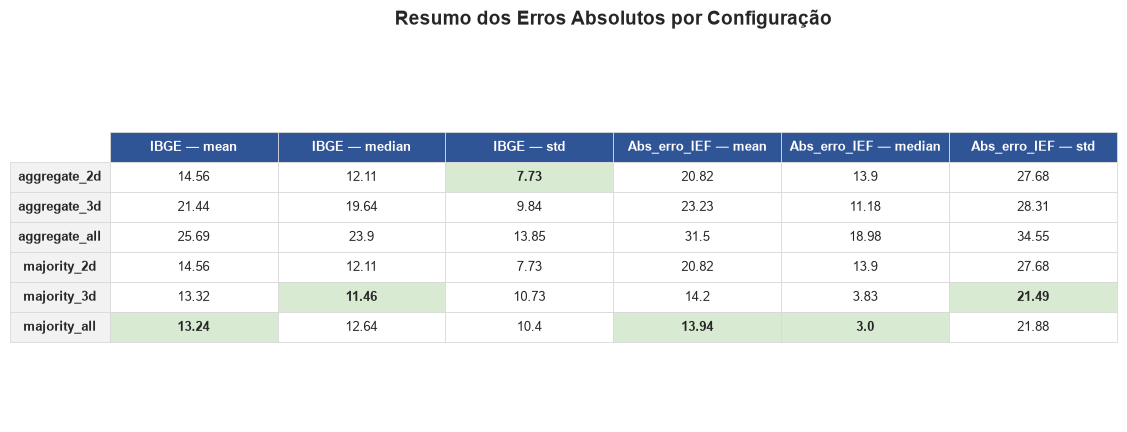

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("comparacao_baselines.csv")

df["Abs_Erro_IBGE_%"] = df["Erro vs IBGE (%)"].abs()
df["Abs_erro_IEF_%"]  = df["Erro vs IEF (%)"].abs()

summary = (df.groupby("Configuração")[["Abs_Erro_IBGE_%", "Abs_erro_IEF_%"]].agg(["mean", "median", "std"]).round(2))

summary.to_csv("tabela_resumo_erros.csv")

table_df = summary.copy()
table_df.columns = [f"{grupo.replace('Abs_Erro_', '').replace('_%', '')} — {estatistica}" for grupo, estatistica in table_df.columns]

table_df = table_df.rename(columns={
    "IBGE: mean": "IBGE\nMédia",
    "IBGE: median": "IBGE\nMediana",
    "IBGE: std": "IBGE\nDesvio-padrão",
    "IEF: mean": "IEF\nMédia",
    "IEF: median": "IEF\nMediana",
    "IEF: std": "IEF\nDesvio-padrão",
})

sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(13, 4.8))
ax.axis("off")

table = ax.table(
    cellText=table_df.values,
    rowLabels=table_df.index,
    colLabels=table_df.columns,
    cellLoc="center",
    rowLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.8)

for (row, col), cell in table.get_celld().items():

    cell.set_edgecolor("#D9D9D9")
    cell.set_linewidth(0.6)

    # Cabeçalho
    if row == 0:
        cell.set_facecolor("#2F5597")
        cell.set_text_props(
            color="white",
            weight="bold"
        )

    # Nome das configurações
    elif col == -1:
        cell.set_facecolor("#F2F2F2")
        cell.set_text_props(weight="bold")

    # Corpo
    else:
        cell.set_facecolor("white")

# Destaque dos menores erros
# Colunas de média/mediana/std
ibge_cols = [0, 1, 2]
ind_cols  = [3, 4, 5]

for cols in [ibge_cols, ind_cols]:

    for col in cols:
        # índice da linha com menor valor
        min_idx = table_df.iloc[:, col].idxmin()
        row_idx = list(table_df.index).index(min_idx) + 1

        table[(row_idx, col)].set_facecolor("#D9EAD3")
        table[(row_idx, col)].set_text_props(weight="bold")

plt.title(
    "Resumo dos Erros Absolutos por Configuração",
    fontsize=14,
    fontweight="bold",
    pad=20
)

#plt.savefig("tabela_resumo_erros.png", dpi=300, bbox_inches="tight", facecolor="white")

plt.savefig("tabela_resumo_erros.pdf", bbox_inches="tight", facecolor="white")

In [7]:
plt.figure(figsize=(12, 7))
ax = sns.boxplot(data=df, x='Configuração', y='Abs_Erro_IBGE_%', palette='Set2')

plt.title('Distribuição do Erro Absoluto (%) em Relação ao IBGE por Configuração', fontsize=14, pad=15)
plt.ylabel('Erro Absoluto (%)', fontsize=12)
plt.xlabel('Configuração (Modo_Arquitetura)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)

plt.tight_layout()
plt.savefig('boxplot_erro_ibge.png', dpi=300) 
plt.close()

best_configs = df[df['Configuração'].isin(['majority_2d', 'majority_3d', 'majority_all'])]

plt.figure(figsize=(14, 7))

sns.barplot(data=best_configs, x='Cidade', y='Abs_Erro_IBGE_%', hue='Configuração', palette='viridis')

plt.title('Comparação de Erro Absoluto (%) por Cidade', fontsize=14, pad=15)
plt.ylabel('Erro Absoluto (%)', fontsize=12)
plt.xlabel('Município', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)

plt.legend(title='Configuração', title_fontsize='12', fontsize='11', loc='upper right')

plt.tight_layout()
plt.savefig('barplot_cidades.png', dpi=300)
plt.close()